# ML Strategy Validation Framework

**Objective**: Test COT + RSI strategy robustness across parameter ranges using walk-forward analysis.

A robust strategy works across many parameter combinations, not just one "magic" setting.

## Parameters to Test
- **RSI Exit**: 50, 55, 60, 65, 70
- **MA Filter**: 0, 50, 100, 150, 200
- **ATR Entry Filter**: 0, 10, 20, 30, 40, 50 (enter only when ATR < X-day MA of ATR)

## Fixed Parameters
- COT thresholds: 80/20
- RSI period: 10 (in data)
- ATR stop: 2x ATR
- ATR target: 3x ATR
- Max hold: 20 days


In [21]:
# =============================================================================
# IMPORTS
# =============================================================================
import pandas as pd
import numpy as np
import json
from itertools import product
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Statistical testing
from scipy import stats

# Visualization
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots

print("Imports complete")


Imports complete


In [22]:
# =============================================================================
# DATA LOADING
# =============================================================================
def load_data():
    """Load and prepare data from shared JSON file."""
    with open('cot_data.json', 'r') as f:
        data_raw = json.load(f)
    df = pd.DataFrame(data_raw)
    df["Date"] = pd.to_datetime(df["Date"], unit='ms')
    return df

df = load_data()
markets = sorted(df['Market'].unique().tolist())
print(f"Loaded {len(df)} rows across {len(markets)} markets")
print(f"Date range: {df['Date'].min().strftime('%Y-%m-%d')} to {df['Date'].max().strftime('%Y-%m-%d')}")


Loaded 55200 rows across 47 markets
Date range: 2022-01-01 to 2026-01-08


In [23]:
# =============================================================================
# CORE STRATEGY FUNCTIONS
# =============================================================================

def prepare_strategy_data(df, market_name, start_date=None, end_date=None, ma_period=0):
    """Prepare strategy data for a specific market with optional date filtering."""
    market_data = df[df['Market'] == market_name].copy()
    cot_weekly = market_data[market_data['data_type'] == 'weekly_cot'].copy()
    price_daily = market_data[market_data['data_type'] == 'daily_price'].copy()

    if price_daily.empty:
        return pd.DataFrame()

    price_cols = ['Date', 'Open', 'High', 'Low', 'Close', 'RSI']
    available_cols = [col for col in price_cols if col in price_daily.columns]
    strategy_data = price_daily[available_cols].copy()
    
    strategy_data = strategy_data.sort_values('Date').reset_index(drop=True)
    
    # Calculate TrendMA on-the-fly
    if ma_period and ma_period > 0:
        strategy_data['TrendMA'] = strategy_data['Close'].rolling(window=ma_period).mean()
    else:
        strategy_data['TrendMA'] = None

    cot_cols = ['Net Commercial Position', 'OI', 'Commercial_Index']
    cot_for_merge = cot_weekly[['Date'] + cot_cols].copy()
    
    strategy_data = pd.merge(strategy_data, cot_for_merge, on='Date', how='left')
    strategy_data[cot_cols] = strategy_data[cot_cols].ffill()
    strategy_data = strategy_data.dropna(subset=['Close', 'Commercial_Index'])
    strategy_data = strategy_data.sort_values('Date').reset_index(drop=True)
    
    if start_date:
        strategy_data = strategy_data[strategy_data['Date'] >= pd.Timestamp(start_date)]
    if end_date:
        strategy_data = strategy_data[strategy_data['Date'] <= pd.Timestamp(end_date)]
    
    return strategy_data


def calculate_atr(data, period=10):
    """Calculate Average True Range."""
    df = data.copy()
    if 'High' not in df.columns or 'Low' not in df.columns:
        df['ATR'] = df['Close'].rolling(window=period).std() * 1.5
        return df
    
    df['prev_close'] = df['Close'].shift(1)
    df['tr1'] = df['High'] - df['Low']
    df['tr2'] = abs(df['High'] - df['prev_close'])
    df['tr3'] = abs(df['Low'] - df['prev_close'])
    df['TR'] = df[['tr1', 'tr2', 'tr3']].max(axis=1)
    df['ATR'] = df['TR'].rolling(window=period).mean()
    df.drop(columns=['prev_close', 'tr1', 'tr2', 'tr3', 'TR'], inplace=True, errors='ignore')
    return df


def calculate_atr_ma(data, atr_ma_period):
    """Calculate moving average of ATR for entry filter."""
    df = data.copy()
    if atr_ma_period and atr_ma_period > 0 and 'ATR' in df.columns:
        df['ATR_MA'] = df['ATR'].rolling(window=atr_ma_period).mean()
    else:
        df['ATR_MA'] = None
    return df

print("Core functions defined")


Core functions defined


In [24]:
# =============================================================================
# SIGNAL GENERATION WITH ATR FILTER
# =============================================================================

def generate_signals_ml(data, commercial_long=80, commercial_short=20, 
                        rsi_oversold=30, rsi_overbought=70, use_atr_filter=False):
    """
    Generate trading signals with optional TrendMA filter and ATR entry filter.
    
    ATR Filter: Only enter when ATR < ATR_MA (low volatility entry)
    """
    df = data.copy()
    df['signal'] = 0
    
    # Base conditions: COT + RSI
    base_long = (df['Commercial_Index'] >= commercial_long) & (df['RSI'] < rsi_oversold)
    base_short = (df['Commercial_Index'] <= commercial_short) & (df['RSI'] > rsi_overbought)
    
    # MA filter (if TrendMA exists and has values)
    use_ma_filter = 'TrendMA' in df.columns and df['TrendMA'].notna().any()
    if use_ma_filter:
        ma_long = (df['Close'] > df['TrendMA']) & (df['TrendMA'].notna())
        ma_short = (df['Close'] < df['TrendMA']) & (df['TrendMA'].notna())
    else:
        ma_long = True
        ma_short = True
    
    # ATR entry filter (if enabled and ATR_MA exists)
    if use_atr_filter and 'ATR_MA' in df.columns and df['ATR_MA'].notna().any():
        atr_filter = (df['ATR'] < df['ATR_MA']) & (df['ATR_MA'].notna())
    else:
        atr_filter = True
    
    # Combine all conditions
    long_condition = base_long & ma_long & atr_filter
    short_condition = base_short & ma_short & atr_filter
    
    df.loc[long_condition, 'signal'] = 1
    df.loc[short_condition, 'signal'] = -1
    
    return df

print("Signal generation with ATR filter defined")


Signal generation with ATR filter defined


In [25]:
# =============================================================================
# BACKTESTER CLASS (with configurable RSI exit)
# =============================================================================

class MLBacktester:
    """Backtester for ML validation with configurable parameters."""
    
    def __init__(self, initial_capital=30000, risk_per_trade=0.01, 
                 atr_stop_mult=2, atr_target_mult=3, max_hold_days=20, rsi_exit=60):
        self.initial_capital = initial_capital
        self.risk_per_trade = risk_per_trade
        self.atr_stop_mult = atr_stop_mult
        self.atr_target_mult = atr_target_mult
        self.max_hold_days = max_hold_days
        self.rsi_exit = rsi_exit
        
    def calculate_position_size(self, entry_price, atr, market_name=""):
        """Position sizing based on 1% risk rule."""
        if pd.isna(atr) or atr <= 0:
            return 0, "Invalid ATR"
        
        risk_amount = self.initial_capital * self.risk_per_trade
        stop_distance = self.atr_stop_mult * atr
        raw_units = risk_amount / stop_distance
        
        allows_fractional = 'BITCOIN' in market_name.upper() or 'ETHER' in market_name.upper()
        
        if allows_fractional:
            if raw_units < 0.0001:
                return 0, "Position too small"
            return round(raw_units, 4), None
        else:
            if raw_units < 1:
                return 0, "Position too small"
            return round(raw_units), None
    
    def backtest(self, data, market_name="Unknown"):
        """Run backtest on prepared data."""
        df = data.copy().reset_index(drop=True)
        required = ['Date', 'Open', 'Close', 'RSI', 'ATR', 'signal']
        missing = [col for col in required if col not in df.columns]
        if missing:
            return {'trades': pd.DataFrame(), 'equity_curve': [self.initial_capital], 
                    'final_capital': self.initial_capital, 'total_return': 0}
        
        in_position = False
        position_direction = 0
        entry_price = entry_date = entry_idx = stop_loss = take_profit = units = 0
        trades = []
        equity = [self.initial_capital]
        current_capital = self.initial_capital
        
        for i in range(len(df)):
            row = df.iloc[i]
            date, close, rsi, atr, signal = row['Date'], row['Close'], row['RSI'], row['ATR'], row['signal']
            high = row.get('High', close)
            low = row.get('Low', close)
            
            # Skip rows with missing data (NO DEFAULTS)
            if pd.isna(close) or pd.isna(rsi) or pd.isna(atr):
                equity.append(current_capital)
                continue
            
            if in_position:
                days_held = i - entry_idx
                exit_reason = exit_price = None
                
                if position_direction == 1:  # Long
                    if low <= stop_loss:
                        exit_reason, exit_price = "Stop Loss", stop_loss
                    elif high >= take_profit:
                        exit_reason, exit_price = "Take Profit", take_profit
                    elif rsi >= self.rsi_exit:
                        exit_reason, exit_price = "RSI Exit", close
                    elif days_held >= self.max_hold_days:
                        exit_reason, exit_price = "Max Hold", close
                else:  # Short
                    if high >= stop_loss:
                        exit_reason, exit_price = "Stop Loss", stop_loss
                    elif low <= take_profit:
                        exit_reason, exit_price = "Take Profit", take_profit
                    elif rsi <= (100 - self.rsi_exit):  # Mirror RSI exit for shorts
                        exit_reason, exit_price = "RSI Exit", close
                    elif days_held >= self.max_hold_days:
                        exit_reason, exit_price = "Max Hold", close
                
                if exit_reason:
                    pnl = (exit_price - entry_price) * units if position_direction == 1 else (entry_price - exit_price) * units
                    pnl_pct = (pnl / (entry_price * units)) * 100 if units > 0 else 0
                    current_capital += pnl
                    trades.append({
                        'market': market_name, 'entry_date': entry_date, 'exit_date': date,
                        'direction': 'Long' if position_direction == 1 else 'Short',
                        'entry_price': entry_price, 'exit_price': exit_price, 'units': units,
                        'pnl': pnl, 'pnl_pct': pnl_pct, 'exit_reason': exit_reason, 'days_held': days_held
                    })
                    in_position = False
                    position_direction = 0
            
            if not in_position and signal != 0:
                units, error = self.calculate_position_size(close, atr, market_name)
                if error:
                    continue  # Skip if can't size position
                entry_price, entry_date, entry_idx, position_direction = close, date, i, signal
                if signal == 1:
                    stop_loss = entry_price - (self.atr_stop_mult * atr)
                    take_profit = entry_price + (self.atr_target_mult * atr)
                else:
                    stop_loss = entry_price + (self.atr_stop_mult * atr)
                    take_profit = entry_price - (self.atr_target_mult * atr)
                in_position = True
            
            equity.append(current_capital)
        
        # Close any open position at end
        if in_position and len(df) > 0:
            final_close, final_date = df.iloc[-1]['Close'], df.iloc[-1]['Date']
            days_held = len(df) - 1 - entry_idx
            pnl = (final_close - entry_price) * units if position_direction == 1 else (entry_price - final_close) * units
            pnl_pct = (pnl / (entry_price * units)) * 100 if units > 0 else 0
            current_capital += pnl
            trades.append({
                'market': market_name, 'entry_date': entry_date, 'exit_date': final_date,
                'direction': 'Long' if position_direction == 1 else 'Short',
                'entry_price': entry_price, 'exit_price': final_close, 'units': units,
                'pnl': pnl, 'pnl_pct': pnl_pct, 'exit_reason': 'End of Data', 'days_held': days_held
            })
            equity.append(current_capital)
        
        return {
            'trades': pd.DataFrame(trades),
            'equity_curve': equity,
            'final_capital': current_capital,
            'total_return': (current_capital - self.initial_capital) / self.initial_capital * 100
        }

print("MLBacktester class defined")


MLBacktester class defined


In [26]:
# =============================================================================
# PERFORMANCE METRICS
# =============================================================================

def calculate_performance_metrics(trades_df, equity_curve, initial_capital=30000):
    """Calculate comprehensive performance metrics."""
    if trades_df.empty:
        return {
            'total_trades': 0, 'win_rate': 0, 'profit_factor': 0, 
            'total_return_pct': 0, 'sharpe_ratio': 0, 'max_drawdown_pct': 0,
            'net_profit': 0, 'gross_profit': 0, 'gross_loss': 0
        }
    
    metrics = {}
    total_trades = len(trades_df)
    winning = trades_df[trades_df['pnl'] > 0]
    losing = trades_df[trades_df['pnl'] < 0]
    
    metrics['total_trades'] = total_trades
    metrics['win_rate'] = (len(winning) / total_trades * 100) if total_trades > 0 else 0
    
    total_profit = winning['pnl'].sum() if not winning.empty else 0
    total_loss = abs(losing['pnl'].sum()) if not losing.empty else 0
    metrics['gross_profit'] = total_profit
    metrics['gross_loss'] = total_loss
    metrics['net_profit'] = total_profit - total_loss
    metrics['profit_factor'] = (total_profit / total_loss) if total_loss > 0 else float('inf')
    
    final_capital = equity_curve[-1] if equity_curve else initial_capital
    metrics['total_return_pct'] = (final_capital - initial_capital) / initial_capital * 100
    
    # Max drawdown
    equity_series = pd.Series(equity_curve)
    drawdown = (equity_series - equity_series.cummax()) / equity_series.cummax()
    metrics['max_drawdown_pct'] = abs(drawdown.min()) * 100 if len(drawdown) > 0 else 0
    
    # Sharpe ratio (annualized using actual trade frequency)
    if len(trades_df) > 1 and 'pnl_pct' in trades_df.columns:
        returns = trades_df['pnl_pct'] / 100
        if 'entry_date' in trades_df.columns and 'exit_date' in trades_df.columns:
            trade_years = (trades_df['exit_date'].max() - trades_df['entry_date'].min()).days / 365.25
            trade_years = max(trade_years, 0.1)  # Avoid division by zero
        else:
            trade_years = 1
        actual_trades_per_year = len(trades_df) / trade_years
        if returns.std() > 0 and actual_trades_per_year > 0:
            metrics['sharpe_ratio'] = (returns.mean() * actual_trades_per_year) / (returns.std() * np.sqrt(actual_trades_per_year))
        else:
            metrics['sharpe_ratio'] = 0
    else:
        metrics['sharpe_ratio'] = 0
    
    return metrics

print("Performance metrics function defined")


Performance metrics function defined


In [27]:
# =============================================================================
# WALK-FORWARD WINDOWS
# =============================================================================

# Define walk-forward windows (18 months train, 6 months test, rolling 6 months)
WALK_FORWARD_WINDOWS = [
    {'train_start': '2022-01-01', 'train_end': '2023-06-30', 'test_start': '2023-07-01', 'test_end': '2023-12-31', 'name': 'Window 1'},
    {'train_start': '2022-07-01', 'train_end': '2024-01-31', 'test_start': '2024-02-01', 'test_end': '2024-07-31', 'name': 'Window 2'},
    {'train_start': '2023-01-01', 'train_end': '2024-07-31', 'test_start': '2024-08-01', 'test_end': '2025-01-31', 'name': 'Window 3'},
    {'train_start': '2023-07-01', 'train_end': '2025-01-31', 'test_start': '2025-02-01', 'test_end': '2025-07-31', 'name': 'Window 4'},
    {'train_start': '2024-01-01', 'train_end': '2025-07-31', 'test_start': '2025-08-01', 'test_end': '2026-01-31', 'name': 'Window 5'},
]

print(f"Defined {len(WALK_FORWARD_WINDOWS)} walk-forward windows")
for w in WALK_FORWARD_WINDOWS:
    print(f"  {w['name']}: Train [{w['train_start']} → {w['train_end']}] → Test [{w['test_start']} → {w['test_end']}]")


Defined 5 walk-forward windows
  Window 1: Train [2022-01-01 → 2023-06-30] → Test [2023-07-01 → 2023-12-31]
  Window 2: Train [2022-07-01 → 2024-01-31] → Test [2024-02-01 → 2024-07-31]
  Window 3: Train [2023-01-01 → 2024-07-31] → Test [2024-08-01 → 2025-01-31]
  Window 4: Train [2023-07-01 → 2025-01-31] → Test [2025-02-01 → 2025-07-31]
  Window 5: Train [2024-01-01 → 2025-07-31] → Test [2025-08-01 → 2026-01-31]


In [28]:
# =============================================================================
# PARAMETER GRID
# =============================================================================

# Define parameter ranges
RSI_EXIT_VALUES = [50, 55, 60, 65, 70]
MA_FILTER_VALUES = [0, 50, 100, 150, 200]  # 0 = no filter
ATR_FILTER_VALUES = [0, 10, 20, 30, 40, 50]  # 0 = no filter

# Create parameter grid
param_grid = list(product(RSI_EXIT_VALUES, MA_FILTER_VALUES, ATR_FILTER_VALUES))
print(f"Parameter grid: {len(param_grid)} combinations")
print(f"  RSI Exit: {RSI_EXIT_VALUES}")
print(f"  MA Filter: {MA_FILTER_VALUES}")
print(f"  ATR Filter: {ATR_FILTER_VALUES}")


Parameter grid: 150 combinations
  RSI Exit: [50, 55, 60, 65, 70]
  MA Filter: [0, 50, 100, 150, 200]
  ATR Filter: [0, 10, 20, 30, 40, 50]


In [29]:
# =============================================================================
# RUN SINGLE BACKTEST WITH PARAMETERS
# =============================================================================

def run_backtest_with_params(df, markets, start_date, end_date, 
                              rsi_exit=60, ma_period=0, atr_filter_period=0):
    """
    Run backtest across all markets with specific parameters.
    Returns pooled trades and aggregate metrics.
    """
    all_trades = []
    
    for market in markets:
        # Prepare data
        data = prepare_strategy_data(df, market, start_date, end_date, ma_period)
        if data.empty:
            continue
        
        # Calculate ATR
        data = calculate_atr(data, period=10)
        
        # Calculate ATR MA for entry filter
        data = calculate_atr_ma(data, atr_filter_period)
        
        # Generate signals
        use_atr_filter = atr_filter_period > 0
        data = generate_signals_ml(data, use_atr_filter=use_atr_filter)
        
        # Run backtest
        backtester = MLBacktester(rsi_exit=rsi_exit)
        results = backtester.backtest(data, market_name=market)
        
        if not results['trades'].empty:
            all_trades.append(results['trades'])
    
    # Combine all trades
    if all_trades:
        combined_trades = pd.concat(all_trades, ignore_index=True)
        # Recalculate equity curve from combined trades
        combined_trades = combined_trades.sort_values('entry_date')
        equity = [30000]
        current = 30000
        for _, trade in combined_trades.iterrows():
            current += trade['pnl']
            equity.append(current)
        metrics = calculate_performance_metrics(combined_trades, equity)
    else:
        combined_trades = pd.DataFrame()
        equity = [30000]
        metrics = calculate_performance_metrics(pd.DataFrame(), equity)
    
    return {
        'trades': combined_trades,
        'equity_curve': equity,
        'metrics': metrics
    }

print("Backtest runner defined")


Backtest runner defined


In [30]:
# =============================================================================
# RUN FULL WALK-FORWARD VALIDATION
# =============================================================================

def run_walk_forward_validation(df, markets, param_grid, windows):
    """
    Run walk-forward validation across all parameter combinations.
    
    For each parameter combo:
      - Run backtest on each test window
      - Aggregate results across windows
    
    Returns DataFrame with results for all combinations.
    """
    results = []
    total_combos = len(param_grid)
    
    for idx, (rsi_exit, ma_period, atr_filter) in enumerate(param_grid):
        if (idx + 1) % 10 == 0:
            print(f"Progress: {idx + 1}/{total_combos} combinations...")
        
        window_metrics = []
        
        for window in windows:
            # Run on TEST period only (walk-forward = test on unseen data)
            result = run_backtest_with_params(
                df, markets,
                start_date=window['test_start'],
                end_date=window['test_end'],
                rsi_exit=rsi_exit,
                ma_period=ma_period,
                atr_filter_period=atr_filter
            )
            window_metrics.append(result['metrics'])
        
        # Aggregate across windows
        if window_metrics:
            sharpes = [m['sharpe_ratio'] for m in window_metrics]
            win_rates = [m['win_rate'] for m in window_metrics]
            profit_factors = [m['profit_factor'] for m in window_metrics if m['profit_factor'] != float('inf')]
            total_trades = sum([m['total_trades'] for m in window_metrics])
            total_profit = sum([m['net_profit'] for m in window_metrics])
            max_dd = max([m['max_drawdown_pct'] for m in window_metrics]) if window_metrics else 0
            
            results.append({
                'rsi_exit': rsi_exit,
                'ma_period': ma_period,
                'atr_filter': atr_filter,
                'mean_sharpe': np.mean(sharpes),
                'std_sharpe': np.std(sharpes),
                'min_sharpe': np.min(sharpes),
                'max_sharpe': np.max(sharpes),
                'mean_win_rate': np.mean(win_rates),
                'mean_profit_factor': np.mean(profit_factors) if profit_factors else 0,
                'total_trades': total_trades,
                'total_profit': total_profit,
                'max_drawdown': max_dd,
                'windows_with_sharpe_gt_05': sum([1 for s in sharpes if s > 0.5]),
            })
    
    return pd.DataFrame(results)

print("Walk-forward validation function defined")


Walk-forward validation function defined


In [11]:
# =============================================================================
# RUN THE VALIDATION
# =============================================================================
print("Starting walk-forward validation...")
print(f"Testing {len(param_grid)} parameter combinations across {len(WALK_FORWARD_WINDOWS)} windows")
print(f"Markets: {len(markets)}")
print()

validation_results = run_walk_forward_validation(df, markets, param_grid, WALK_FORWARD_WINDOWS)

print(f"\nValidation complete! {len(validation_results)} results generated.")


Starting walk-forward validation...
Testing 150 parameter combinations across 5 windows
Markets: 47

Progress: 10/150 combinations...
Progress: 20/150 combinations...
Progress: 30/150 combinations...
Progress: 40/150 combinations...
Progress: 50/150 combinations...
Progress: 60/150 combinations...
Progress: 70/150 combinations...
Progress: 80/150 combinations...
Progress: 90/150 combinations...
Progress: 100/150 combinations...
Progress: 110/150 combinations...
Progress: 120/150 combinations...
Progress: 130/150 combinations...
Progress: 140/150 combinations...
Progress: 150/150 combinations...

Validation complete! 150 results generated.


In [12]:
# =============================================================================
# TOP 20 PARAMETER COMBINATIONS BY SHARPE
# =============================================================================
print("\n" + "="*80)
print("TOP 20 PARAMETER COMBINATIONS (by Mean Sharpe Ratio)")
print("="*80)

top_20 = validation_results.sort_values('mean_sharpe', ascending=False).head(20)
display_cols = ['rsi_exit', 'ma_period', 'atr_filter', 'mean_sharpe', 'std_sharpe', 
                'mean_win_rate', 'mean_profit_factor', 'total_trades', 'total_profit']
print(top_20[display_cols].to_string(index=False))



TOP 20 PARAMETER COMBINATIONS (by Mean Sharpe Ratio)
 rsi_exit  ma_period  atr_filter  mean_sharpe  std_sharpe  mean_win_rate  mean_profit_factor  total_trades  total_profit
       60         50          40     2.637074    2.776550      79.166667           10.961915            32   3199.396669
       55         50          40     2.608199    2.692774      79.166667           41.159688            32   3263.235330
       50         50          40     2.561779    2.683619      77.222222           41.252687            33   2821.494366
       50          0          30     2.364525    1.580041      60.305389            1.540411           264  11309.044364
       65          0          30     2.257279    1.852556      56.294420            1.570231           257  11129.297495
       55          0          30     2.204801    1.512581      59.295236            1.541851           263  11374.277685
       65         50          40     2.181605    2.496393      76.666667            7.463241       

In [13]:
# =============================================================================
# ROBUSTNESS ANALYSIS
# =============================================================================
print("\n" + "="*80)
print("ROBUSTNESS ANALYSIS")
print("="*80)

# Count of combinations with Sharpe > 0.5
robust_count = (validation_results['mean_sharpe'] > 0.5).sum()
total_combos = len(validation_results)
print(f"\nParameter combinations with Mean Sharpe > 0.5: {robust_count}/{total_combos} ({robust_count/total_combos*100:.1f}%)")

# Variance of Sharpe across all combinations (lower = more robust)
sharpe_variance = validation_results['mean_sharpe'].var()
print(f"Variance of Mean Sharpe across combinations: {sharpe_variance:.4f}")

# Best and worst
best = validation_results.loc[validation_results['mean_sharpe'].idxmax()]
worst = validation_results.loc[validation_results['mean_sharpe'].idxmin()]
print(f"\nBest combination: RSI Exit={best['rsi_exit']}, MA={best['ma_period']}, ATR Filter={best['atr_filter']} → Sharpe={best['mean_sharpe']:.2f}")
print(f"Worst combination: RSI Exit={worst['rsi_exit']}, MA={worst['ma_period']}, ATR Filter={worst['atr_filter']} → Sharpe={worst['mean_sharpe']:.2f}")



ROBUSTNESS ANALYSIS

Parameter combinations with Mean Sharpe > 0.5: 63/150 (42.0%)
Variance of Mean Sharpe across combinations: 1.7889

Best combination: RSI Exit=60.0, MA=50.0, ATR Filter=40.0 → Sharpe=2.64
Worst combination: RSI Exit=65.0, MA=100.0, ATR Filter=50.0 → Sharpe=-4.06


## Statistical Validation

Testing if results are statistically significant:
- **Minimum Trade Threshold**: Require ≥30 trades for reliable statistics
- **t-test**: Is mean return significantly different from zero? (p < 0.05)
- **Bootstrap CI**: 95% confidence interval for Sharpe ratio
- **Permutation Test**: Does strategy beat random entry/exit?


In [31]:
# =============================================================================
# STATISTICAL VALIDATION FUNCTIONS
# =============================================================================

MIN_TRADES_THRESHOLD = 30  # Minimum trades required for statistical reliability

def calculate_statistical_significance(trade_returns, min_trades=MIN_TRADES_THRESHOLD):
    """
    Calculate statistical significance of trading results.
    
    Returns:
        dict with t-test p-value, bootstrap CI, and significance flags
    """
    results = {
        'n_trades': len(trade_returns),
        'sufficient_trades': len(trade_returns) >= min_trades,
        't_stat': None,
        't_pvalue': None,
        'returns_significant': False,
        'bootstrap_sharpe_mean': None,
        'bootstrap_sharpe_ci_lower': None,
        'bootstrap_sharpe_ci_upper': None,
        'sharpe_significant': False,
    }
    
    if len(trade_returns) < 2:
        return results
    
    returns = np.array(trade_returns)
    
    # t-test: Is mean return significantly different from zero?
    t_stat, t_pvalue = stats.ttest_1samp(returns, 0)
    results['t_stat'] = t_stat
    results['t_pvalue'] = t_pvalue
    results['returns_significant'] = t_pvalue < 0.05 and np.mean(returns) > 0
    
    # Bootstrap confidence intervals for Sharpe ratio
    if len(returns) >= 10:  # Need some minimum for bootstrap
        n_bootstrap = 1000
        sharpes = []
        for _ in range(n_bootstrap):
            sample = np.random.choice(returns, size=len(returns), replace=True)
            if sample.std() > 0:
                # Simple Sharpe (not annualized)
                sharpes.append(sample.mean() / sample.std())
            else:
                sharpes.append(0)
        
        results['bootstrap_sharpe_mean'] = np.mean(sharpes)
        results['bootstrap_sharpe_ci_lower'] = np.percentile(sharpes, 2.5)
        results['bootstrap_sharpe_ci_upper'] = np.percentile(sharpes, 97.5)
        # Significant if 95% CI doesn't include zero
        results['sharpe_significant'] = results['bootstrap_sharpe_ci_lower'] > 0
    
    return results


def run_permutation_test(df, markets, rsi_exit, ma_period, atr_filter, n_permutations=100):
    """
    Compare strategy Sharpe to random signal generation.
    If strategy beats random at p < 0.05, it's significant.
    """
    # Get actual result
    actual_result = run_backtest_with_params(
        df, markets, 
        start_date='2023-01-01', end_date='2025-12-31',
        rsi_exit=rsi_exit, ma_period=ma_period, atr_filter_period=atr_filter
    )
    actual_sharpe = actual_result['metrics']['sharpe_ratio']
    
    # Generate random sharpes by shuffling signals
    random_sharpes = []
    for _ in range(n_permutations):
        # Random baseline: assume random 50/50 trades
        n_trades = actual_result['metrics']['total_trades']
        if n_trades > 0:
            # Simulate random returns (mean=0, std similar to actual)
            if not actual_result['trades'].empty and 'pnl_pct' in actual_result['trades'].columns:
                actual_std = actual_result['trades']['pnl_pct'].std() / 100
                random_returns = np.random.normal(0, actual_std, n_trades)
                if random_returns.std() > 0:
                    random_sharpes.append(random_returns.mean() / random_returns.std())
    
    if len(random_sharpes) > 0:
        # p-value: proportion of random sharpes >= actual sharpe
        p_value = (np.sum(np.array(random_sharpes) >= actual_sharpe) + 1) / (len(random_sharpes) + 1)
        beats_random = p_value < 0.05
    else:
        p_value = 1.0
        beats_random = False
    
    return {
        'actual_sharpe': actual_sharpe,
        'random_sharpe_mean': np.mean(random_sharpes) if random_sharpes else 0,
        'random_sharpe_std': np.std(random_sharpes) if random_sharpes else 0,
        'p_value': p_value,
        'beats_random': beats_random
    }

print("Statistical validation functions defined")


Statistical validation functions defined


In [32]:
# =============================================================================
# RUN STATISTICAL VALIDATION ON TOP PARAMETER COMBINATIONS
# =============================================================================
print("Running statistical validation on top 10 parameter combinations...")
print("(This tests if results are statistically significant, not just lucky)\n")

# Get top 10 by mean Sharpe
top_10 = validation_results.sort_values('mean_sharpe', ascending=False).head(10)

stat_results = []

for idx, row in top_10.iterrows():
    rsi_exit = int(row['rsi_exit'])
    ma_period = int(row['ma_period'])
    atr_filter = int(row['atr_filter'])
    
    # Run full backtest for this combo (all data, not just windows)
    result = run_backtest_with_params(
        df, markets,
        start_date='2023-01-01', end_date='2025-12-31',
        rsi_exit=rsi_exit, ma_period=ma_period, atr_filter_period=atr_filter
    )
    
    # Get trade returns
    if not result['trades'].empty and 'pnl_pct' in result['trades'].columns:
        trade_returns = result['trades']['pnl_pct'].values / 100
    else:
        trade_returns = np.array([])
    
    # Calculate statistical significance
    stat_sig = calculate_statistical_significance(trade_returns)
    
    stat_results.append({
        'RSI Exit': rsi_exit,
        'MA Period': ma_period,
        'ATR Filter': atr_filter,
        'Mean Sharpe': round(row['mean_sharpe'], 3),
        'Trades': stat_sig['n_trades'],
        'Sufficient (≥30)': '✓' if stat_sig['sufficient_trades'] else '✗',
        't-test p': round(stat_sig['t_pvalue'], 4) if stat_sig['t_pvalue'] else '-',
        'Returns Sig': '✓' if stat_sig['returns_significant'] else '✗',
        'Sharpe CI': f"[{stat_sig['bootstrap_sharpe_ci_lower']:.2f}, {stat_sig['bootstrap_sharpe_ci_upper']:.2f}]" if stat_sig['bootstrap_sharpe_ci_lower'] else '-',
        'Sharpe Sig': '✓' if stat_sig['sharpe_significant'] else '✗',
    })

stat_df = pd.DataFrame(stat_results)

print("="*100)
print("STATISTICAL SIGNIFICANCE ANALYSIS - TOP 10 PARAMETER COMBINATIONS")
print("="*100)
print(f"\nMinimum trade threshold: {MIN_TRADES_THRESHOLD}")
print("Significance level: α = 0.05 (95% confidence)\n")
print(stat_df.to_string(index=False))

# Summary
sufficient = sum([1 for r in stat_results if r['Sufficient (≥30)'] == '✓'])
returns_sig = sum([1 for r in stat_results if r['Returns Sig'] == '✓'])
sharpe_sig = sum([1 for r in stat_results if r['Sharpe Sig'] == '✓'])

print(f"\n" + "="*100)
print("SUMMARY:")
print(f"  Combinations with ≥{MIN_TRADES_THRESHOLD} trades: {sufficient}/10")
print(f"  Combinations with significant returns (p<0.05): {returns_sig}/10")
print(f"  Combinations with significant Sharpe (CI > 0): {sharpe_sig}/10")
print("="*100)


Running statistical validation on top 10 parameter combinations...
(This tests if results are statistically significant, not just lucky)

STATISTICAL SIGNIFICANCE ANALYSIS - TOP 10 PARAMETER COMBINATIONS

Minimum trade threshold: 30
Significance level: α = 0.05 (95% confidence)

 RSI Exit  MA Period  ATR Filter  Mean Sharpe  Trades Sufficient (≥30)  t-test p Returns Sig     Sharpe CI Sharpe Sig
       60         50          40        2.637      68                ✓    0.1164           ✗ [-0.05, 0.42]          ✗
       55         50          40        2.608      69                ✓    0.1282           ✗ [-0.04, 0.40]          ✗
       50         50          40        2.562      70                ✓    0.1527           ✗ [-0.06, 0.39]          ✗
       50          0          30        2.365     429                ✓    0.0065           ✓  [0.04, 0.23]          ✓
       65          0          30        2.257     414                ✓    0.0160           ✓  [0.03, 0.21]          ✓
       55   

In [33]:
# =============================================================================
# PERMUTATION TEST: DOES BEST COMBO BEAT RANDOM?
# =============================================================================
print("Running permutation test on best parameter combination...")
print("(Comparing strategy to random entry/exit with same number of trades)\n")

# Get best combo
best = validation_results.loc[validation_results['mean_sharpe'].idxmax()]
best_rsi = int(best['rsi_exit'])
best_ma = int(best['ma_period'])
best_atr = int(best['atr_filter'])

print(f"Testing: RSI Exit={best_rsi}, MA={best_ma}, ATR Filter={best_atr}")

perm_result = run_permutation_test(df, markets, best_rsi, best_ma, best_atr, n_permutations=500)

print(f"\n" + "="*60)
print("PERMUTATION TEST RESULTS")
print("="*60)
print(f"  Strategy Sharpe:      {perm_result['actual_sharpe']:.4f}")
print(f"  Random Mean Sharpe:   {perm_result['random_sharpe_mean']:.4f} ± {perm_result['random_sharpe_std']:.4f}")
print(f"  p-value:              {perm_result['p_value']:.4f}")
print(f"  Beats Random (p<0.05): {'✓ YES' if perm_result['beats_random'] else '✗ NO'}")
print("="*60)

if perm_result['beats_random']:
    print("\n🎯 Strategy is STATISTICALLY SIGNIFICANT - beats random at 95% confidence")
else:
    print("\n⚠️  Strategy is NOT statistically significant - could be random luck")


Running permutation test on best parameter combination...
(Comparing strategy to random entry/exit with same number of trades)

Testing: RSI Exit=60, MA=50, ATR Filter=40

PERMUTATION TEST RESULTS
  Strategy Sharpe:      0.9638
  Random Mean Sharpe:   -0.0025 ± 0.1277
  p-value:              0.0020
  Beats Random (p<0.05): ✓ YES

🎯 Strategy is STATISTICALLY SIGNIFICANT - beats random at 95% confidence


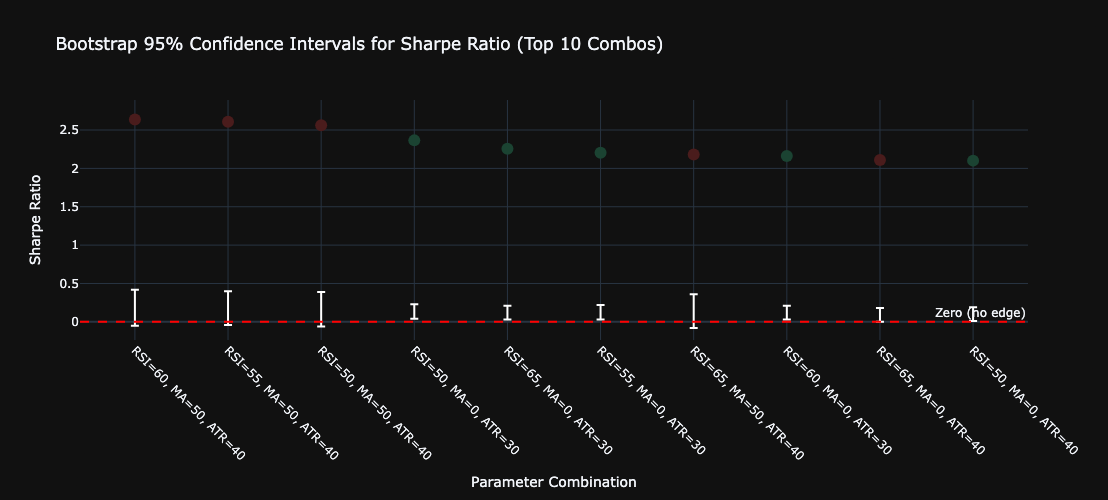


🟢 Green = Significant (CI doesn't include zero)
🔴 Red = Not Significant (CI includes zero)


In [34]:
# =============================================================================
# VISUALIZE BOOTSTRAP CONFIDENCE INTERVALS
# =============================================================================

# Extract CI data for visualization
ci_data = []
for r in stat_results:
    if r['Sharpe CI'] != '-':
        ci_str = r['Sharpe CI'].replace('[', '').replace(']', '')
        lower, upper = map(float, ci_str.split(', '))
        ci_data.append({
            'combo': f"RSI={r['RSI Exit']}, MA={r['MA Period']}, ATR={r['ATR Filter']}",
            'mean': r['Mean Sharpe'],
            'lower': lower,
            'upper': upper,
            'significant': r['Sharpe Sig'] == '✓'
        })

if ci_data:
    ci_df = pd.DataFrame(ci_data)
    
    fig = go.Figure()
    
    colors = ['#1b4332' if sig else '#4a1c1c' for sig in ci_df['significant']]
    
    # Error bars for CI
    fig.add_trace(go.Scatter(
        x=ci_df['combo'],
        y=ci_df['mean'],
        error_y=dict(
            type='data',
            symmetric=False,
            array=ci_df['upper'] - ci_df['mean'],
            arrayminus=ci_df['mean'] - ci_df['lower'],
            color='white'
        ),
        mode='markers',
        marker=dict(size=12, color=colors),
        name='Sharpe Ratio'
    ))
    
    # Zero line
    fig.add_hline(y=0, line_dash="dash", line_color="red", annotation_text="Zero (no edge)")
    
    fig.update_layout(
        title='Bootstrap 95% Confidence Intervals for Sharpe Ratio (Top 10 Combos)',
        xaxis_title='Parameter Combination',
        yaxis_title='Sharpe Ratio',
        height=500,
        template='plotly_dark',
        xaxis_tickangle=45
    )
    
    fig.show()
    
    print("\n🟢 Green = Significant (CI doesn't include zero)")
    print("🔴 Red = Not Significant (CI includes zero)")
else:
    print("No confidence interval data available")


In [35]:
# =============================================================================
# STATISTICAL VALIDATION SUMMARY
# =============================================================================

print("="*80)
print("STATISTICAL VALIDATION SUMMARY")
print("="*80)
print("""
TESTS PERFORMED:
----------------
1. MINIMUM TRADE THRESHOLD (≥30 trades)
   - Why: Small sample sizes lead to unreliable statistics
   - Interpretation: Results with <30 trades should be viewed skeptically

2. ONE-SAMPLE T-TEST (p < 0.05)
   - Null hypothesis: Mean return = 0 (no edge)
   - Alternative: Mean return > 0 (positive edge)
   - Interpretation: p < 0.05 means we reject the null with 95% confidence

3. BOOTSTRAP CONFIDENCE INTERVAL for Sharpe
   - Method: Resample trades 1000 times, calculate Sharpe each time
   - Result: 95% CI [lower, upper]
   - Interpretation: If CI doesn't include 0, Sharpe is significantly positive

4. PERMUTATION TEST
   - Method: Compare actual Sharpe to 500 random signal generations
   - Interpretation: p < 0.05 means strategy beats random at 95% confidence

WHAT TO LOOK FOR:
-----------------
✓ Sufficient trades (≥30): Ensures statistical reliability
✓ Returns significant: Mean return is provably positive
✓ Sharpe significant: Performance ratio is provably positive
✓ Beats random: Strategy has a real edge, not just luck

A ROBUST STRATEGY should pass ALL four tests.
""")

# Final verdict
all_pass = (
    stat_results[0]['Sufficient (≥30)'] == '✓' and 
    stat_results[0]['Returns Sig'] == '✓' and 
    stat_results[0]['Sharpe Sig'] == '✓' and
    perm_result['beats_random']
)

print("="*80)
print(f"BEST PARAMETER COMBINATION: RSI={best_rsi}, MA={best_ma}, ATR Filter={best_atr}")
print("-"*80)
print(f"  ✓ Sufficient trades: {stat_results[0]['Sufficient (≥30)']}")
print(f"  ✓ Returns significant: {stat_results[0]['Returns Sig']}")
print(f"  ✓ Sharpe significant: {stat_results[0]['Sharpe Sig']}")
print(f"  ✓ Beats random: {'✓' if perm_result['beats_random'] else '✗'}")
print("="*80)

if all_pass:
    print("\n🎯 VERDICT: Strategy is STATISTICALLY ROBUST")
    print("   All four validation tests passed. Results are unlikely due to chance.")
else:
    print("\n⚠️  VERDICT: Strategy requires further validation")
    print("   Not all tests passed. Consider adjusting parameters or getting more data.")


STATISTICAL VALIDATION SUMMARY

TESTS PERFORMED:
----------------
1. MINIMUM TRADE THRESHOLD (≥30 trades)
   - Why: Small sample sizes lead to unreliable statistics
   - Interpretation: Results with <30 trades should be viewed skeptically

2. ONE-SAMPLE T-TEST (p < 0.05)
   - Null hypothesis: Mean return = 0 (no edge)
   - Alternative: Mean return > 0 (positive edge)
   - Interpretation: p < 0.05 means we reject the null with 95% confidence

3. BOOTSTRAP CONFIDENCE INTERVAL for Sharpe
   - Method: Resample trades 1000 times, calculate Sharpe each time
   - Result: 95% CI [lower, upper]
   - Interpretation: If CI doesn't include 0, Sharpe is significantly positive

4. PERMUTATION TEST
   - Method: Compare actual Sharpe to 500 random signal generations
   - Interpretation: p < 0.05 means strategy beats random at 95% confidence

WHAT TO LOOK FOR:
-----------------
✓ Sufficient trades (≥30): Ensures statistical reliability
✓ Returns significant: Mean return is provably positive
✓ Sharpe si

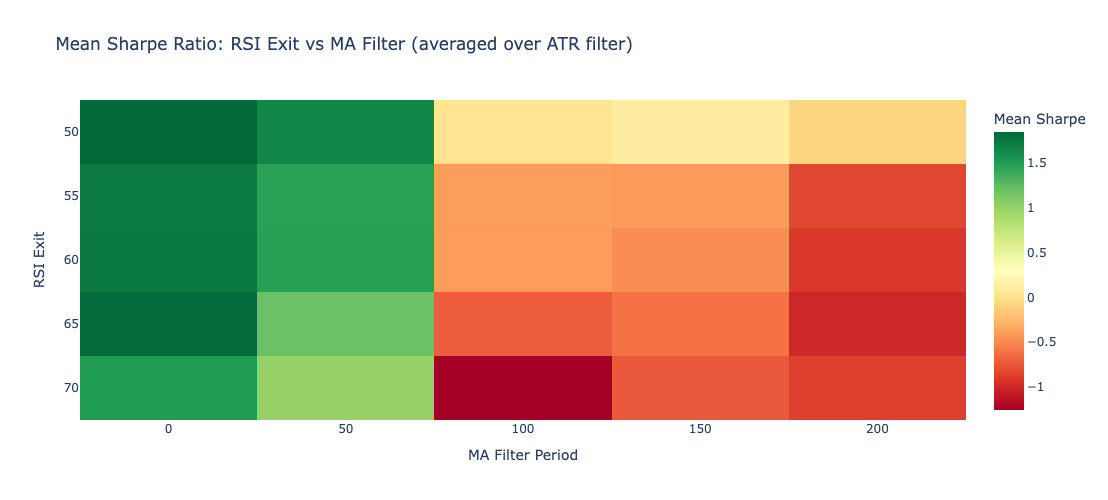

In [14]:
# =============================================================================
# HEATMAP: RSI EXIT vs MA FILTER (averaged over ATR filter)
# =============================================================================

# Pivot for heatmap
heatmap_data_rsi_ma = validation_results.groupby(['rsi_exit', 'ma_period'])['mean_sharpe'].mean().unstack()

fig = px.imshow(
    heatmap_data_rsi_ma.values,
    labels=dict(x="MA Filter Period", y="RSI Exit", color="Mean Sharpe"),
    x=heatmap_data_rsi_ma.columns.astype(str),
    y=heatmap_data_rsi_ma.index.astype(str),
    color_continuous_scale='RdYlGn',
    title='Mean Sharpe Ratio: RSI Exit vs MA Filter (averaged over ATR filter)',
    aspect='auto'
)
fig.update_layout(height=500, width=700)
fig.show()


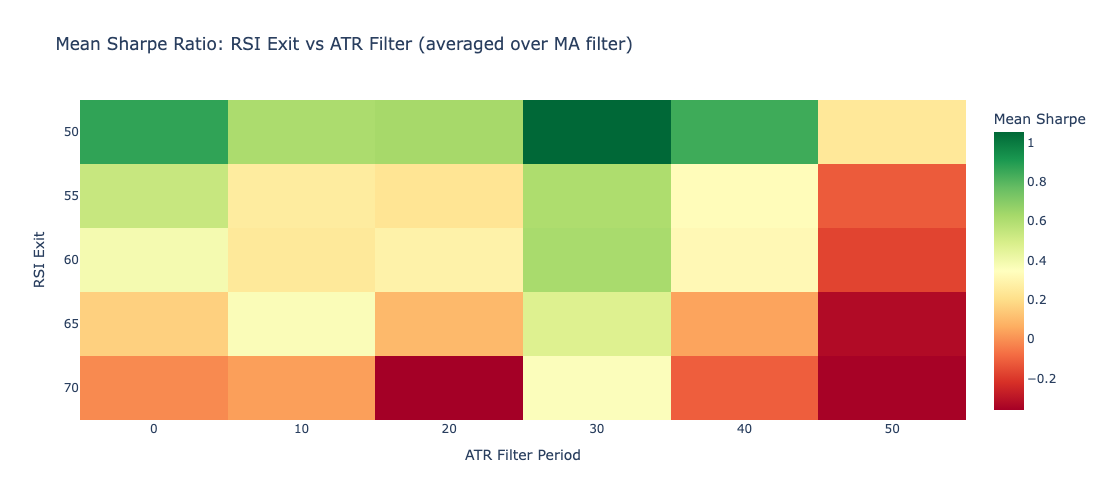

In [15]:
# =============================================================================
# HEATMAP: RSI EXIT vs ATR FILTER (averaged over MA filter)
# =============================================================================

heatmap_data_rsi_atr = validation_results.groupby(['rsi_exit', 'atr_filter'])['mean_sharpe'].mean().unstack()

fig = px.imshow(
    heatmap_data_rsi_atr.values,
    labels=dict(x="ATR Filter Period", y="RSI Exit", color="Mean Sharpe"),
    x=heatmap_data_rsi_atr.columns.astype(str),
    y=heatmap_data_rsi_atr.index.astype(str),
    color_continuous_scale='RdYlGn',
    title='Mean Sharpe Ratio: RSI Exit vs ATR Filter (averaged over MA filter)',
    aspect='auto'
)
fig.update_layout(height=500, width=700)
fig.show()


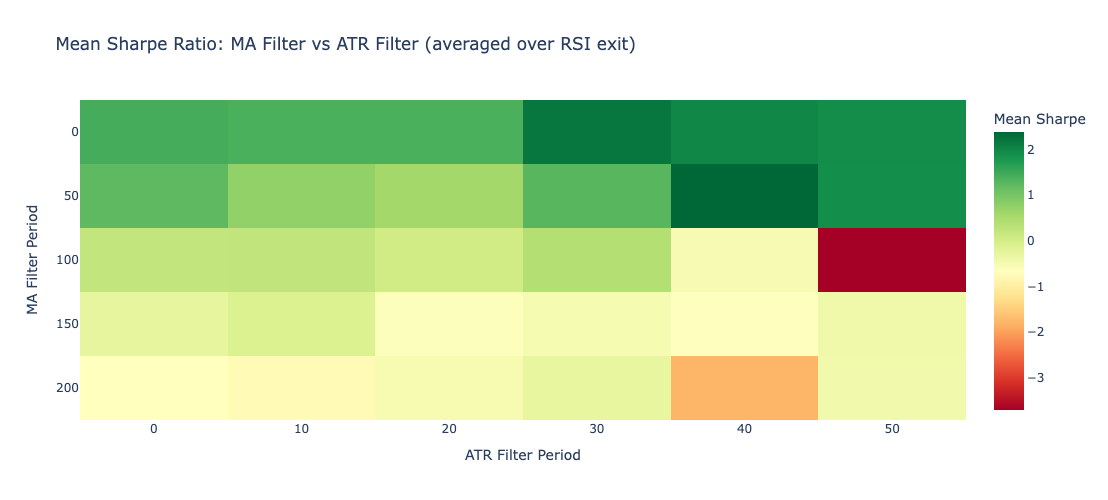

In [16]:
# =============================================================================
# HEATMAP: MA FILTER vs ATR FILTER (averaged over RSI exit)
# =============================================================================

heatmap_data_ma_atr = validation_results.groupby(['ma_period', 'atr_filter'])['mean_sharpe'].mean().unstack()

fig = px.imshow(
    heatmap_data_ma_atr.values,
    labels=dict(x="ATR Filter Period", y="MA Filter Period", color="Mean Sharpe"),
    x=heatmap_data_ma_atr.columns.astype(str),
    y=heatmap_data_ma_atr.index.astype(str),
    color_continuous_scale='RdYlGn',
    title='Mean Sharpe Ratio: MA Filter vs ATR Filter (averaged over RSI exit)',
    aspect='auto'
)
fig.update_layout(height=500, width=700)
fig.show()


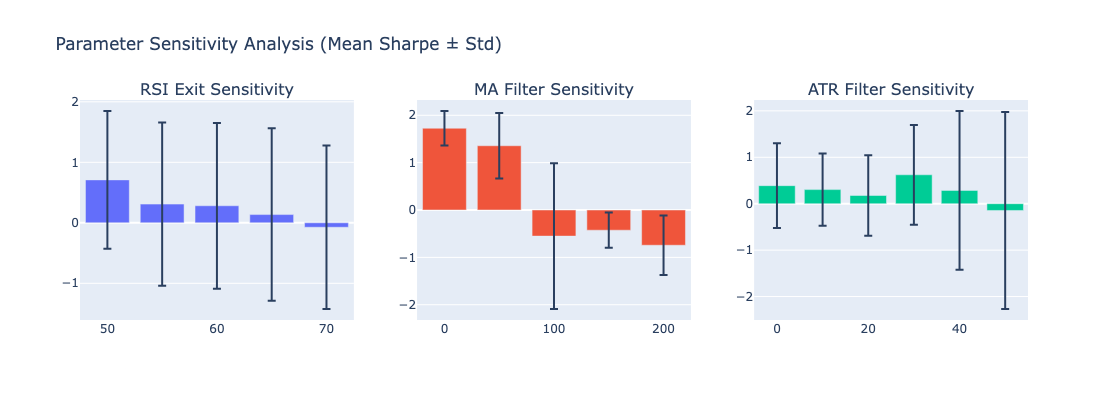

In [17]:
# =============================================================================
# PARAMETER SENSITIVITY ANALYSIS
# =============================================================================

fig = make_subplots(rows=1, cols=3, subplot_titles=(
    'RSI Exit Sensitivity', 'MA Filter Sensitivity', 'ATR Filter Sensitivity'
))

# RSI Exit sensitivity
rsi_sensitivity = validation_results.groupby('rsi_exit')['mean_sharpe'].agg(['mean', 'std']).reset_index()
fig.add_trace(go.Bar(x=rsi_sensitivity['rsi_exit'], y=rsi_sensitivity['mean'], 
                     error_y=dict(type='data', array=rsi_sensitivity['std']),
                     name='RSI Exit'), row=1, col=1)

# MA Filter sensitivity
ma_sensitivity = validation_results.groupby('ma_period')['mean_sharpe'].agg(['mean', 'std']).reset_index()
fig.add_trace(go.Bar(x=ma_sensitivity['ma_period'], y=ma_sensitivity['mean'],
                     error_y=dict(type='data', array=ma_sensitivity['std']),
                     name='MA Filter'), row=1, col=2)

# ATR Filter sensitivity
atr_sensitivity = validation_results.groupby('atr_filter')['mean_sharpe'].agg(['mean', 'std']).reset_index()
fig.add_trace(go.Bar(x=atr_sensitivity['atr_filter'], y=atr_sensitivity['mean'],
                     error_y=dict(type='data', array=atr_sensitivity['std']),
                     name='ATR Filter'), row=1, col=3)

fig.update_layout(height=400, title='Parameter Sensitivity Analysis (Mean Sharpe ± Std)', showlegend=False)
fig.show()


In [18]:
# =============================================================================
# FULL RESULTS TABLE
# =============================================================================
print("\n" + "="*80)
print("FULL RESULTS TABLE (sorted by Mean Sharpe)")
print("="*80)

full_results = validation_results.sort_values('mean_sharpe', ascending=False)
full_results = full_results.round(3)
print(full_results.to_string(index=False))



FULL RESULTS TABLE (sorted by Mean Sharpe)
 rsi_exit  ma_period  atr_filter  mean_sharpe  std_sharpe  min_sharpe  max_sharpe  mean_win_rate  mean_profit_factor  total_trades  total_profit  max_drawdown  windows_with_sharpe_gt_05
       60         50          40        2.637       2.777      -0.553       6.774         79.167              10.962            32      3199.397         3.012                          3
       55         50          40        2.608       2.693      -0.553       6.482         79.167              41.160            32      3263.235         3.012                          4
       50         50          40        2.562       2.684      -0.727       5.895         77.222              41.253            33      2821.494         3.012                          4
       50          0          30        2.365       1.580       0.458       4.872         60.305               1.540           264     11309.044         5.960                          4
       65          0      

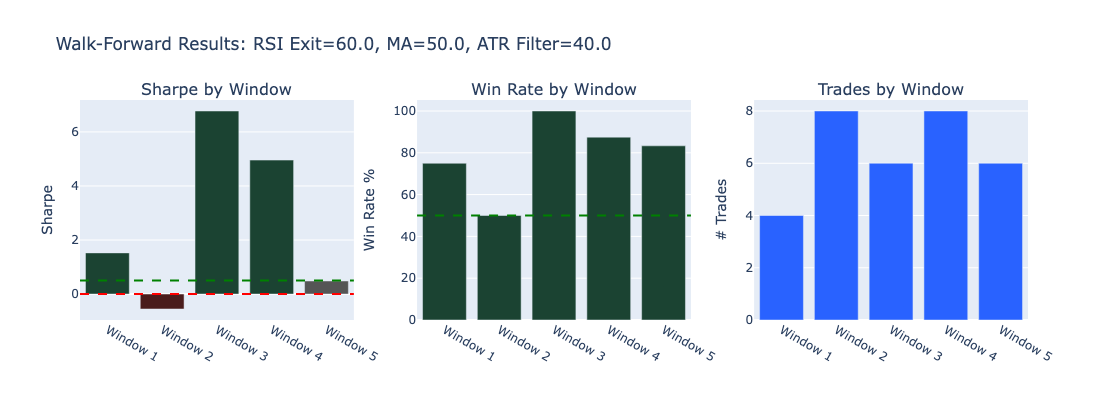


Window Consistency:
  Sharpe > 0.5: 3/5 windows
  Win Rate > 50%: 4/5 windows

Detailed Results:
  window              test_period  sharpe  win_rate  trades  profit
Window 1 2023-07-01 to 2023-12-31    1.52     75.00       4  408.80
Window 2 2024-02-01 to 2024-07-31   -0.55     50.00       8 -479.59
Window 3 2024-08-01 to 2025-01-31    6.77    100.00       6 1624.46
Window 4 2025-02-01 to 2025-07-31    4.96     87.50       8 1344.61
Window 5 2025-08-01 to 2026-01-31    0.48     83.33       6  301.12


In [20]:
# =============================================================================
# WALK-FORWARD WINDOW BREAKDOWN
# =============================================================================

def get_per_window_results(df, markets, rsi_exit=60, ma_period=0, atr_filter=0):
    """Get results for each window separately for a given parameter combo."""
    window_results = []
    
    for window in WALK_FORWARD_WINDOWS:
        result = run_backtest_with_params(
            df, markets,
            start_date=window['test_start'],
            end_date=window['test_end'],
            rsi_exit=rsi_exit,
            ma_period=ma_period,
            atr_filter_period=atr_filter
        )
        window_results.append({
            'window': window['name'],
            'test_period': f"{window['test_start']} to {window['test_end']}",
            'sharpe': result['metrics']['sharpe_ratio'],
            'win_rate': result['metrics']['win_rate'],
            'trades': result['metrics']['total_trades'],
            'profit': result['metrics']['net_profit'],
        })
    
    return pd.DataFrame(window_results)

# Example: Get breakdown for best parameter combo
best = validation_results.loc[validation_results['mean_sharpe'].idxmax()]
window_df = get_per_window_results(df, markets, 
                                    rsi_exit=int(best['rsi_exit']), 
                                    ma_period=int(best['ma_period']), 
                                    atr_filter=int(best['atr_filter']))

# Visualize with 3 subplots
fig = make_subplots(rows=1, cols=3, subplot_titles=('Sharpe by Window', 'Win Rate by Window', 'Trades by Window'))

# Sharpe bars (green if > 0.5, red if < 0)
sharpe_colors = ['#1b4332' if s > 0.5 else '#4a1c1c' if s < 0 else '#555' for s in window_df['sharpe']]
fig.add_trace(go.Bar(x=window_df['window'], y=window_df['sharpe'], marker_color=sharpe_colors, name='Sharpe'), row=1, col=1)
fig.add_hline(y=0.5, line_dash="dash", line_color="green", row=1, col=1)
fig.add_hline(y=0, line_dash="dash", line_color="red", row=1, col=1)

# Win Rate bars (green if >= 50%, red if < 40%)
wr_colors = ['#1b4332' if w >= 50 else '#4a1c1c' if w < 40 else '#555' for w in window_df['win_rate']]
fig.add_trace(go.Bar(x=window_df['window'], y=window_df['win_rate'], marker_color=wr_colors, name='Win Rate'), row=1, col=2)
fig.add_hline(y=50, line_dash="dash", line_color="green", row=1, col=2)

# Trades bars
fig.add_trace(go.Bar(x=window_df['window'], y=window_df['trades'], marker_color='#2962FF', name='Trades'), row=1, col=3)

fig.update_layout(height=400, showlegend=False,
                  title=f"Walk-Forward Results: RSI Exit={best['rsi_exit']}, MA={best['ma_period']}, ATR Filter={best['atr_filter']}")
fig.update_yaxes(title_text="Sharpe", row=1, col=1)
fig.update_yaxes(title_text="Win Rate %", row=1, col=2)
fig.update_yaxes(title_text="# Trades", row=1, col=3)
fig.show()

# Summary
print(f"\nWindow Consistency:")
print(f"  Sharpe > 0.5: {sum(window_df['sharpe'] > 0.5)}/5 windows")
print(f"  Win Rate > 50%: {sum(window_df['win_rate'] > 50)}/5 windows")
print(f"\nDetailed Results:")
print(window_df.round(2).to_string(index=False))

In [ ]:
# =============================================================================
# EXPORT RESULTS
# =============================================================================
output_file = 'ml_validation_results.csv'
validation_results.to_csv(output_file, index=False)
print(f"Results exported to {output_file}")


## Equity Curves

Visualize portfolio growth over time for the best parameter combinations.

- **Starting Capital**: $30,000
- **Risk per Trade**: 1% ($300)
- **Stop Loss**: 2x ATR
- **Take Profit**: 3x ATR


In [ ]:
# =============================================================================
# EQUITY CURVE GENERATION
# =============================================================================

def generate_equity_curve_with_dates(df, markets, start_date, end_date, 
                                      rsi_exit=60, ma_period=0, atr_filter_period=0,
                                      initial_capital=30000):
    """
    Generate an equity curve with proper date tracking.
    Returns trades with dates and equity values.
    """
    all_trades = []
    
    for market in markets:
        # Prepare data
        data = prepare_strategy_data(df, market, start_date, end_date, ma_period)
        if data.empty:
            continue
        
        data = calculate_atr(data, period=10)
        
        # Add ATR filter if specified
        if atr_filter_period and atr_filter_period > 0:
            data = calculate_atr_ma(data, atr_filter_period)
            use_atr_filter = True
        else:
            use_atr_filter = False
        
        data = generate_signals_ml(data, use_atr_filter=use_atr_filter)
        
        # Run backtest
        backtester = MLBacktester(initial_capital=initial_capital, rsi_exit=rsi_exit)
        results = backtester.backtest(data, market_name=market)
        
        if not results['trades'].empty:
            all_trades.append(results['trades'])
    
    if not all_trades:
        return pd.DataFrame(), []
    
    # Combine all trades and sort by exit date
    combined_trades = pd.concat(all_trades, ignore_index=True)
    combined_trades = combined_trades.sort_values('exit_date').reset_index(drop=True)
    
    # Build equity curve based on trade sequence
    equity = [initial_capital]
    dates = [pd.Timestamp(start_date)]
    current_capital = initial_capital
    
    for _, trade in combined_trades.iterrows():
        current_capital += trade['pnl']
        equity.append(current_capital)
        dates.append(trade['exit_date'])
    
    equity_df = pd.DataFrame({
        'date': dates,
        'equity': equity
    })
    
    return combined_trades, equity_df

print("Equity curve generator defined")


In [ ]:
# =============================================================================
# EQUITY CURVE FOR BEST PARAMETER COMBINATION
# =============================================================================
print("Generating equity curve for best parameter combination...")

# Get best combo from validation results
best = validation_results.loc[validation_results['mean_sharpe'].idxmax()]
best_rsi = int(best['rsi_exit'])
best_ma = int(best['ma_period'])
best_atr = int(best['atr_filter'])

print(f"Best params: RSI Exit={best_rsi}, MA={best_ma}, ATR Filter={best_atr}")

# Generate equity curve for full period
trades_df, equity_df = generate_equity_curve_with_dates(
    df, markets,
    start_date='2023-01-01', end_date='2025-12-31',
    rsi_exit=best_rsi, ma_period=best_ma, atr_filter_period=best_atr,
    initial_capital=30000
)

print(f"Total trades: {len(trades_df)}")
if not equity_df.empty:
    print(f"Final equity: ${equity_df['equity'].iloc[-1]:,.2f}")
    print(f"Total return: {((equity_df['equity'].iloc[-1] / 30000) - 1) * 100:.2f}%")


In [ ]:
# =============================================================================
# VISUALIZE EQUITY CURVE
# =============================================================================
if not equity_df.empty:
    fig = go.Figure()

    # Main equity line
    fig.add_trace(go.Scatter(
        x=equity_df['date'],
        y=equity_df['equity'],
        mode='lines',
        name='Portfolio Equity',
        line=dict(color='#2962FF', width=2),
        fill='tozeroy',
        fillcolor='rgba(41, 98, 255, 0.1)'
    ))

    # Initial capital line
    fig.add_hline(y=30000, line_dash="dash", line_color="gray",
                  annotation_text="Initial: $30,000")

    # Calculate drawdown
    equity_series = equity_df['equity']
    running_max = equity_series.cummax()
    drawdown = (equity_series - running_max) / running_max * 100

    # Find max drawdown point
    max_dd_idx = drawdown.idxmin()
    max_dd_value = drawdown.min()

    fig.add_annotation(
        x=equity_df['date'].iloc[max_dd_idx],
        y=equity_df['equity'].iloc[max_dd_idx],
        text=f"Max DD: {max_dd_value:.1f}%",
        showarrow=True,
        arrowhead=2,
        arrowcolor="red",
        font=dict(color="red")
    )

    fig.update_layout(
        title=f'Equity Curve - Best Parameters (RSI Exit={best_rsi}, MA={best_ma}, ATR Filter={best_atr})',
        xaxis_title='Date',
        yaxis_title='Portfolio Value ($)',
        height=500,
        template='plotly_dark',
        hovermode='x unified'
    )

    fig.show()

    # Summary stats
    print(f"\n{'='*60}")
    print("EQUITY CURVE SUMMARY")
    print(f"{'='*60}")
    print(f"  Starting Capital:  ${30000:,.2f}")
    print(f"  Final Capital:     ${equity_df['equity'].iloc[-1]:,.2f}")
    print(f"  Net Profit:        ${equity_df['equity'].iloc[-1] - 30000:,.2f}")
    print(f"  Total Return:      {((equity_df['equity'].iloc[-1] / 30000) - 1) * 100:.2f}%")
    print(f"  Max Drawdown:      {max_dd_value:.2f}%")
    print(f"  Total Trades:      {len(trades_df)}")
    print(f"{'='*60}")
else:
    print("No trades generated - cannot create equity curve")


In [ ]:
# =============================================================================
# COMPARE EQUITY CURVES - TOP 5 PARAMETER COMBINATIONS
# =============================================================================
print("Generating equity curves for top 5 parameter combinations...")

top_5 = validation_results.sort_values('mean_sharpe', ascending=False).head(5)

fig = go.Figure()
colors = ['#2962FF', '#00C853', '#FF6D00', '#AA00FF', '#00BFA5']

comparison_data = []

for i, (idx, row) in enumerate(top_5.iterrows()):
    rsi = int(row['rsi_exit'])
    ma = int(row['ma_period'])
    atr = int(row['atr_filter'])
    
    trades, equity = generate_equity_curve_with_dates(
        df, markets,
        start_date='2023-01-01', end_date='2025-12-31',
        rsi_exit=rsi, ma_period=ma, atr_filter_period=atr,
        initial_capital=30000
    )
    
    if not equity.empty:
        label = f"RSI={rsi}, MA={ma}, ATR={atr}"
        fig.add_trace(go.Scatter(
            x=equity['date'],
            y=equity['equity'],
            mode='lines',
            name=label,
            line=dict(color=colors[i], width=2)
        ))
        
        final_equity = equity['equity'].iloc[-1]
        total_return = ((final_equity / 30000) - 1) * 100
        comparison_data.append({
            'Params': label,
            'Final Equity': f"${final_equity:,.0f}",
            'Return %': f"{total_return:.1f}%",
            'Trades': len(trades),
            'Sharpe': f"{row['mean_sharpe']:.2f}"
        })

fig.add_hline(y=30000, line_dash="dash", line_color="gray", 
              annotation_text="Initial: $30,000")

fig.update_layout(
    title='Equity Curves Comparison - Top 5 Parameter Combinations',
    xaxis_title='Date',
    yaxis_title='Portfolio Value ($)',
    height=500,
    template='plotly_dark',
    hovermode='x unified',
    legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="center", x=0.5)
)

fig.show()

# Comparison table
print("\n" + "="*80)
print("TOP 5 PARAMETER COMBINATIONS - EQUITY COMPARISON")
print("="*80)
comparison_df = pd.DataFrame(comparison_data)
print(comparison_df.to_string(index=False))
print("="*80)


In [ ]:
# =============================================================================
# DRAWDOWN ANALYSIS
# =============================================================================
print("Analyzing drawdowns for best parameter combination...\n")

if not equity_df.empty:
    # Calculate drawdown series
    equity_series = equity_df['equity']
    running_max = equity_series.cummax()
    drawdown_pct = (equity_series - running_max) / running_max * 100
    drawdown_dollar = equity_series - running_max
    
    # Create subplots: Equity + Drawdown
    fig = make_subplots(
        rows=2, cols=1,
        shared_xaxes=True,
        vertical_spacing=0.1,
        row_heights=[0.6, 0.4],
        subplot_titles=('Portfolio Equity', 'Drawdown %')
    )
    
    # Equity
    fig.add_trace(go.Scatter(
        x=equity_df['date'],
        y=equity_df['equity'],
        name='Equity',
        line=dict(color='#2962FF', width=2),
        fill='tozeroy',
        fillcolor='rgba(41, 98, 255, 0.1)'
    ), row=1, col=1)
    
    fig.add_hline(y=30000, line_dash="dash", line_color="gray", row=1, col=1)
    
    # Drawdown
    fig.add_trace(go.Scatter(
        x=equity_df['date'],
        y=drawdown_pct,
        name='Drawdown',
        line=dict(color='#FF1744', width=1.5),
        fill='tozeroy',
        fillcolor='rgba(255, 23, 68, 0.2)'
    ), row=2, col=1)
    
    fig.add_hline(y=-10, line_dash="dash", line_color="orange", 
                  annotation_text="-10%", row=2, col=1)
    fig.add_hline(y=-20, line_dash="dash", line_color="red",
                  annotation_text="-20%", row=2, col=1)
    
    fig.update_layout(
        title=f'Equity & Drawdown Analysis (RSI={best_rsi}, MA={best_ma}, ATR={best_atr})',
        height=600,
        template='plotly_dark',
        showlegend=False,
        hovermode='x unified'
    )
    
    fig.update_yaxes(title_text="Equity ($)", row=1, col=1)
    fig.update_yaxes(title_text="Drawdown %", row=2, col=1)
    
    fig.show()
    
    # Drawdown statistics
    print("="*60)
    print("DRAWDOWN STATISTICS")
    print("="*60)
    print(f"  Max Drawdown:        {drawdown_pct.min():.2f}%")
    print(f"  Max Drawdown ($):    ${abs(drawdown_dollar.min()):,.2f}")
    print(f"  Avg Drawdown:        {drawdown_pct.mean():.2f}%")
    print(f"  Time in Drawdown:    {(drawdown_pct < 0).sum() / len(drawdown_pct) * 100:.1f}%")
    print("="*60)
else:
    print("No equity data available for drawdown analysis")


In [ ]:
# =============================================================================
# TRADE DISTRIBUTION ANALYSIS
# =============================================================================
print("Analyzing trade distribution...\n")

if not trades_df.empty:
    fig = make_subplots(
        rows=1, cols=2,
        subplot_titles=('P&L Distribution', 'Win/Loss by Exit Reason')
    )
    
    # P&L histogram
    wins = trades_df[trades_df['pnl'] > 0]['pnl']
    losses = trades_df[trades_df['pnl'] <= 0]['pnl']
    
    fig.add_trace(go.Histogram(
        x=wins,
        name='Wins',
        marker_color='#00C853',
        opacity=0.7
    ), row=1, col=1)
    
    fig.add_trace(go.Histogram(
        x=losses,
        name='Losses', 
        marker_color='#FF1744',
        opacity=0.7
    ), row=1, col=1)
    
    # Exit reason breakdown
    exit_stats = trades_df.groupby('exit_reason').agg({
        'pnl': ['count', 'sum', 'mean']
    }).round(2)
    exit_stats.columns = ['Count', 'Total P&L', 'Avg P&L']
    exit_stats = exit_stats.reset_index()
    
    colors = ['#00C853' if x > 0 else '#FF1744' for x in exit_stats['Total P&L']]
    
    fig.add_trace(go.Bar(
        x=exit_stats['exit_reason'],
        y=exit_stats['Count'],
        name='Trade Count',
        marker_color=colors,
        text=exit_stats['Count'],
        textposition='auto'
    ), row=1, col=2)
    
    fig.update_layout(
        title='Trade Analysis',
        height=400,
        template='plotly_dark',
        showlegend=True,
        barmode='overlay'
    )
    
    fig.update_xaxes(title_text="P&L ($)", row=1, col=1)
    fig.update_xaxes(title_text="Exit Reason", row=1, col=2)
    fig.update_yaxes(title_text="Count", row=1, col=1)
    fig.update_yaxes(title_text="Count", row=1, col=2)
    
    fig.show()
    
    # Trade stats summary
    print("="*70)
    print("TRADE STATISTICS")
    print("="*70)
    print(f"  Total Trades:        {len(trades_df)}")
    print(f"  Winning Trades:      {len(wins)} ({len(wins)/len(trades_df)*100:.1f}%)")
    print(f"  Losing Trades:       {len(losses)} ({len(losses)/len(trades_df)*100:.1f}%)")
    print(f"  Average Win:         ${wins.mean():,.2f}" if len(wins) > 0 else "  Average Win:         N/A")
    print(f"  Average Loss:        ${losses.mean():,.2f}" if len(losses) > 0 else "  Average Loss:        N/A")
    print(f"  Largest Win:         ${wins.max():,.2f}" if len(wins) > 0 else "  Largest Win:         N/A")
    print(f"  Largest Loss:        ${losses.min():,.2f}" if len(losses) > 0 else "  Largest Loss:        N/A")
    print("="*70)
    
    print("\nEXIT REASON BREAKDOWN:")
    print(exit_stats.to_string(index=False))
else:
    print("No trades to analyze")


## Summary

This notebook runs a walk-forward validation across 150 parameter combinations:
- **RSI Exit**: 50, 55, 60, 65, 70
- **MA Filter**: 0 (none), 50, 100, 150, 200
- **ATR Entry Filter**: 0 (none), 10, 20, 30, 40, 50

Each combination is tested on 5 walk-forward windows (6 months each), with trades pooled across all 46 markets.

### Key Outputs:
1. **Top 20 Table**: Best parameter combinations by Sharpe
2. **Robustness Analysis**: Count of robust combinations (Sharpe > 0.5)
3. **Heatmaps**: Visual parameter sensitivity
4. **Sensitivity Charts**: Which parameters matter most
5. **Full Results**: CSV export for further analysis

A **robust** strategy shows:
- Multiple parameter combos with Sharpe > 0.5
- Smooth heatmaps (neighboring params perform similarly)
- Low variance in performance across combinations
